In [1]:
#Importing libraries
import snafu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unidecode
from spellchecker import SpellChecker
import os
import nltk
import collections
import json
import statsmodels.api as sm
import networkx as nx
from scipy.stats import kruskal
import scikit_posthocs as sp
from scipy.stats import entropy
from scipy.stats import entropy as shannon_entropy
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import spearmanr, pearsonr, shapiro
import plotly.graph_objects as go
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import defaultdict
from tqdm import tqdm
from Levenshtein import distance as levenshtein_distance

## Pre-processing

In [2]:
!pip install spacy
!python -m spacy download it_core_news_sm


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 95.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('it_core_news_sm')


In [3]:
import requests
import spacy
import unidecode

nlp = spacy.load("it_core_news_sm")

# Download the list of the 50,000 most frequent Italian words
url = "https://raw.githubusercontent.com/hermitdave/FrequencyWords/master/content/2016/it/it_50k.txt"
response = requests.get(url)
lines = response.text.splitlines()

global_dict = set()

for line in lines:
    word = line.split()[0]  
    word = unidecode.unidecode(word.lower())
    doc = nlp(word)
    if doc and doc[0].is_alpha:
        lemma = doc[0].lemma_
        global_dict.add(lemma)

In [4]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [5]:
from nltk.tokenize import word_tokenize
from spellchecker import SpellChecker
import spacy

# Load models
nltk.download('punkt')
nlp = spacy.load("it_core_news_sm")
spell_it = SpellChecker(language='it')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [6]:
# Tracking words not found
not_found = []

# Normalization function
def preprocess(word):
    word = str(word).lower()
    word = unidecode.unidecode(word)
    word = word.replace("-", "")
    doc = nlp(word)
    if doc and doc[0].is_alpha:
        return doc[0].lemma_
    return word

# Semantic Levenshtein
def levenshtein_distance(s1, s2):
    if s1 == s2: return 0
    if len(s1) < len(s2): s1, s2 = s2, s1
    previous = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous[j + 1] + 1
            deletions = current[j] + 1
            substitutions = previous[j] + (c1 != c2)
            current.append(min(insertions, deletions, substitutions))
        previous = current
    return previous[-1]

# Levenshtein correction
def correct_with_levenshtein(word, dictionary):
    best_match = word
    best_dist = 2  # max accepted distance
    for candidate in dictionary:
        dist = levenshtein_distance(word, candidate)
        if dist < best_dist:
            best_match = candidate
            best_dist = dist
    return best_match

In [7]:
not_found = []

def clean_word(word):
    word = preprocess(word)

    # Step 1: Direct match
    if word in global_dict:
        return word

    # Step 2: Levenshtein correction
    corrected = correct_with_levenshtein(word, global_dict)
    if corrected != word:
        return corrected

    # Step 3: Spell checker (Italian)
    suggestion = spell_it.correction(word)
    if suggestion:
        lemma = preprocess(suggestion)
        if lemma in global_dict:
            return lemma

    not_found.append(word)
    return None

In [8]:
def clean_sentence(text):
    if pd.isnull(text):
        return []
    tokens = word_tokenize(text, language='italian')
    cleaned = [clean_word(t) for t in tokens if t.isalpha()]
    return [w for w in cleaned if w is not None]

In [9]:
df_resp = pd.read_excel("DATASET FINALIZZATA_PIT_resp_13.04.xlsx")

In [10]:
df_resp["clean answers"] = df_resp["transcription"].apply(clean_sentence)

In [11]:
print("Not found:", set(not_found))

Not found: {'lavagnetta', 'appollaiato', 'sedendoso', 'stravogliere', 'accovacciato', 'scherzoso', 'sbigottito', 'attaccandolo'}


In [12]:
manual_corrections = {
    "stravogliere": "stravolgere",
    "lavagnetta": "lavagna",
    "attaccandolo": "attaccare"
}

In [13]:
def preprocess(word):
    word = str(word).lower()
    word = unidecode.unidecode(word).replace("-", "")
    doc = nlp(word)
    for token in doc:
        if token.is_alpha:
            return token.lemma_
    return word


In [14]:
def recover_and_integrate(not_found, global_dict):
    excluded = {"sedendoso"}
    added_lemmas = {}

    for word in set(not_found):
        if word in excluded:
            continue

        # Check manual corrections
        if word in manual_corrections:
            lemma = manual_corrections[word]
        else:
            lemma = preprocess(word)

        global_dict.add(lemma)
        added_lemmas[word] = lemma

    print("Lemmas added to dictionary:")
    for original, lemma in sorted(added_lemmas.items()):
        print(f"  {original} → {lemma}")

    print("Words excluded:", sorted(excluded))


In [15]:
global_dict = set()

recover_and_integrate(not_found, global_dict)

Lemmas added to dictionary:
  accovacciato → accovacciare
  appollaiato → appollaiare
  attaccandolo → attaccare
  lavagnetta → lavagna
  sbigottito → sbigottire
  scherzoso → scherzoso
  stravogliere → stravolgere
Words excluded: ['sedendoso']


In [16]:
for answers in df_resp["clean answers"]:
    if isinstance(answers, list):
        global_dict.update(answers)

In [17]:
df_resp["clean answers"] = df_resp["transcription"].apply(clean_sentence)

In [18]:
def normalize_only(text):
    if pd.isnull(text):
        return []
    text = str(text).lower()
    text = unidecode.unidecode(text)
    tokens = word_tokenize(text, language='italian')
    lemmas = []
    for token in tokens:
        if token.isalpha():
            doc = nlp(token)
            lemmas.append(doc[0].lemma_)
    return lemmas

df_resp["id"] = df_resp["id"].astype(str).str.strip()

# Select participant
X = "11"
participant = df_resp[df_resp["id"] == X]

if not participant.empty:
    row = participant.iloc[0]
    
    original = row["transcription"]
    step2 = normalize_only(original)
    step3 = clean_sentence(original)
    
    print("Step 1 — Original text:")
    print(original, "\n")
    
    print("Step 2 — Normalized tokens:")
    print(step2, "\n")
    
    print("Step 3 — Semantically cleaned tokens:")
    print(step3, "\n")
else:
    print(f"No participant found with id = {X}")


Step 1 — Original text:
Vedo delle ragazze che indicano un video sul computer. Una la lavagnetta di sughero. Giovani positive. In piedi su una sedia, sempre in piedi accovacciate una bella notizia. Vedo uno chito in ginocchio  sta mettendo a posto una presa. Hanno perso qualcosa che stanno cercando. Un'altra ipotesi, sono spavetate, un animale, un topo. 

Step 2 — Normalized tokens:
['vedere', 'di il', 'ragazzo', 'che', 'indicare', 'uno', 'video', 'su il', 'computer', 'uno', 'il', 'lavagnetta', 'di', 'sughero', 'giovane', 'positivo', 'in', 'piede', 'su', 'uno', 'sediare', 'sempre', 'in', 'piede', 'accovacciare', 'uno', 'bello', 'notizia', 'vedere', 'uno', 'chire', 'in', 'ginocchio', 'stare', 'mettere', 'a', 'posto', 'uno', 'prendere', 'avere', 'perso', 'qualcosa', 'che', 'stare', 'cercare', 'ipotesi', 'essere', 'spavetare', 'uno', 'animale', 'uno', 'topo'] 

Step 3 — Semantically cleaned tokens:
['vedere', 'di il', 'ragazzo', 'che', 'indicare', 'uno', 'video', 'su il', 'computer', 'uno

## Construction of individual semantic networks

In [19]:
def build_semantic_network(words, window_size=2):
    G = nx.Graph()
    for i in range(len(words) - window_size + 1):
        window = words[i:i + window_size]
        for j in range(len(window)):
            for k in range(j + 1, len(window)):
                w1, w2 = window[j], window[k]
                if w1 == w2:
                    continue
                if G.has_edge(w1, w2):
                    G[w1][w2]['weight'] += 1
                else:
                    G.add_edge(w1, w2, weight=1)
    return G

In [32]:
from collections import Counter

semantic_graphs = {}

for idx, row in df_resp.iterrows():
    words = row["clean answers"]
    if isinstance(words, list) and words:
        G = build_semantic_network(words, window_size=2)
        
        # Add frequencies as node attributes
        word_counts = Counter(words)
        for word, count in word_counts.items():
            G.add_node(word, frequency=count)
        
        participant_id = row["id"]
        semantic_graphs[str(participant_id)] = G


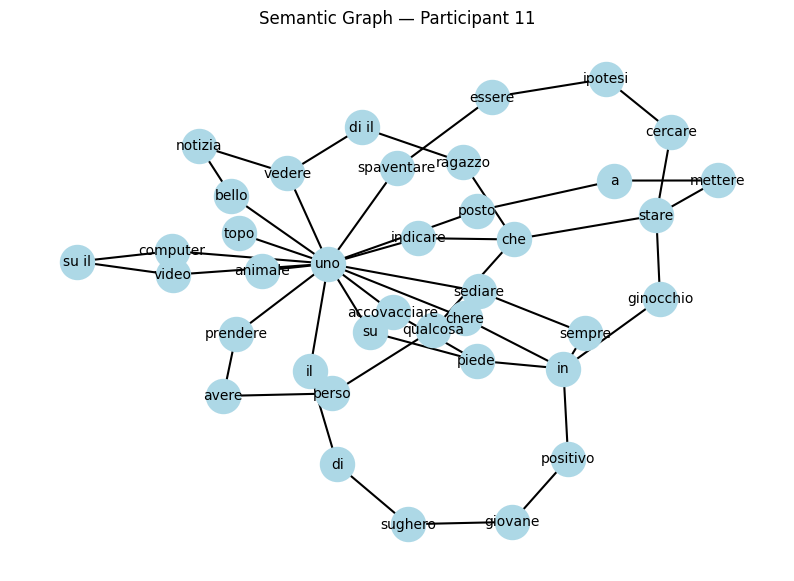

In [26]:
participant_id = "11"

if participant_id in semantic_graphs:
    G = semantic_graphs[participant_id]

    plt.figure(figsize=(10, 7))
    
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=600)
    nx.draw_networkx_edges(G, pos, width=1.5)
    nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif')
    
    plt.title(f"Semantic Graph — Participant {participant_id}")
    plt.axis('off')
    plt.show()
else:
    print(f"No graph found for participant ID = {participant_id}")


## Network metrics

Metric	                                         Definition	
Entropy	                                         Measures the distribution of node degrees (Shannon entropy).	
Number of Nodes	                         Total number of unique concepts in the network.	
Number of Edges	                         Total number of connections (co-occurrences) between concepts.	
Network Density	                         Ratio of actual to possible connections in the network.	
Clustering Coefficient	                 Likelihood that nodes form local triangles (cohesive subgroups).	
Semantic Clustering (K-means)	 Grouping participants by semantic profiles (e.g., flexibility + efficiency).	
Silhouette Score	                         Evaluation of clustering quality (range: –1 to +1).	

In [34]:
#Entropy (based on degree distribution)
def compute_entropy(G):
    degrees = [deg for _, deg in G.degree()]
    if not degrees or sum(degrees) == 0:
        return 0.0
    prob_dist = np.array(degrees) / sum(degrees)
    return entropy(prob_dist, base=2)

In [35]:
df_resp["NumNodes"] = df_resp["id"].map(lambda i: semantic_graphs[i].number_of_nodes() if i in semantic_graphs else 0)
df_resp["NumArches"] = df_resp["id"].map(lambda i: semantic_graphs[i].number_of_edges() if i in semantic_graphs else 0)
df_resp["Clustering"] = df_resp["id"].map(lambda i: nx.average_clustering(semantic_graphs[i]) if i in semantic_graphs else 0.0)
df_resp["Density"] = df_resp["id"].map(lambda i: nx.density(semantic_graphs[i]) if i in semantic_graphs else 0.0)
df_resp["Entropy"] = df_resp["id"].map(lambda i: compute_entropy(semantic_graphs[i]) if i in semantic_graphs else 0.0)

In [36]:
words_control = sum(df_resp[df_resp["group"] == "HC"]["clean answers"], [])
words_mci = sum(df_resp[df_resp["group"] == "MCI"]["clean answers"], [])
words_frailty = sum(df_resp[df_resp["group"] == "Frailty"]["clean answers"], [])

In [37]:
G_control = build_semantic_network(words_control, window_size=2)
G_mci = build_semantic_network(words_mci, window_size=2)
G_frailty = build_semantic_network(words_frailty, window_size=2)

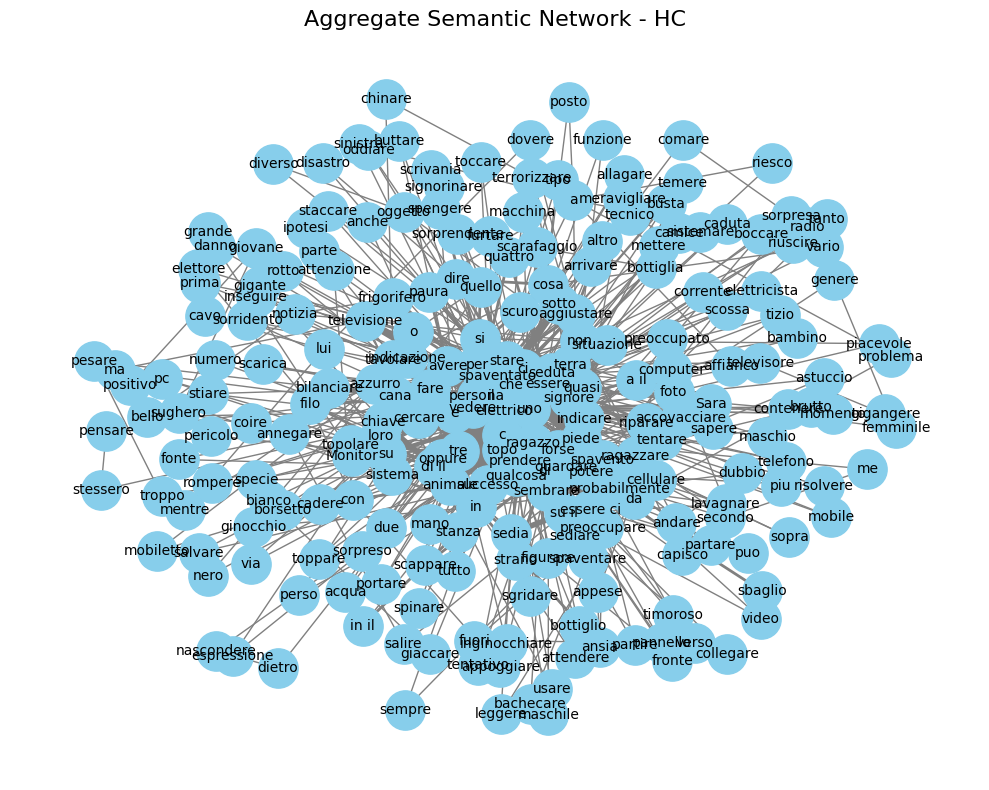

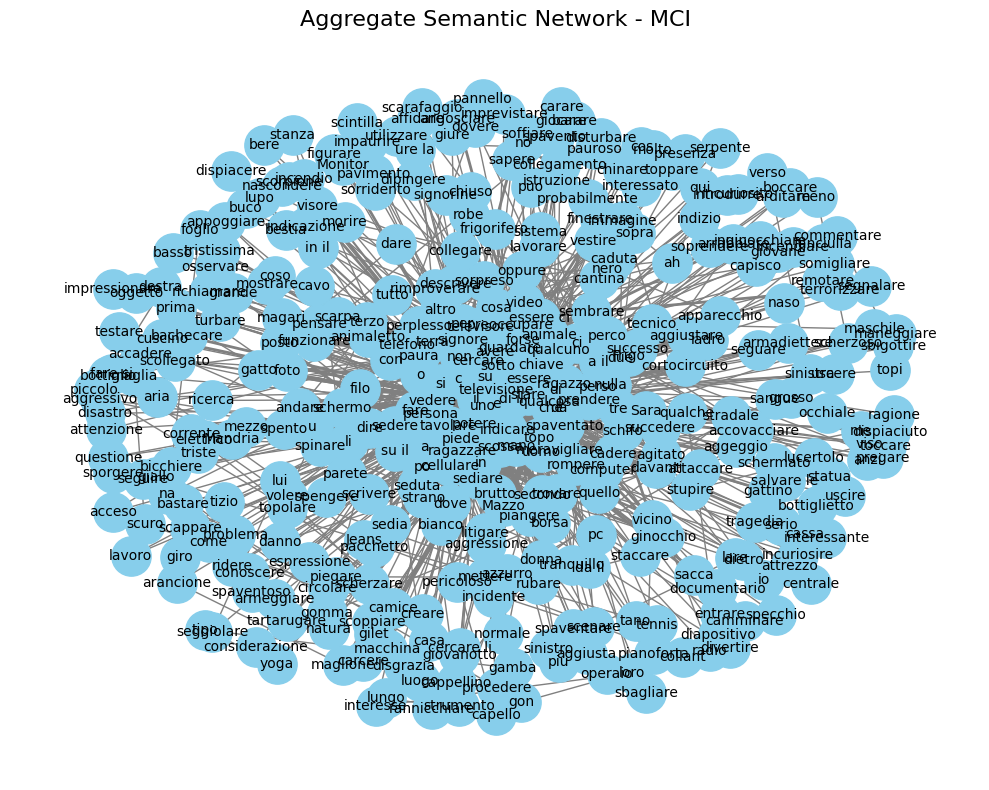

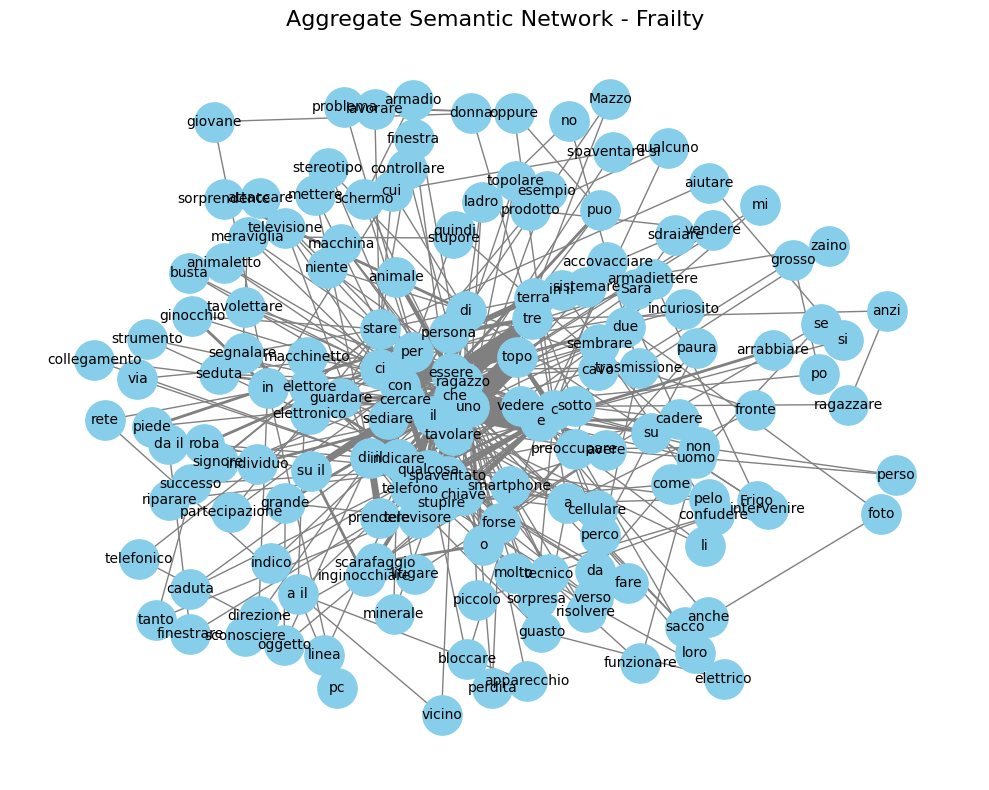

In [38]:
def draw_graph(G, title):
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=0.5, seed=42)
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=800)
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")
    
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_graph(G_control, "Aggregate Semantic Network - HC")
draw_graph(G_mci, "Aggregate Semantic Network - MCI")
draw_graph(G_frailty, "Aggregate Semantic Network - Frailty")

In [39]:
def compute_global_metrics(G):
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    density = nx.density(G)
    clustering = nx.average_clustering(G)
    avg_degree = sum(dict(G.degree()).values()) / num_nodes if num_nodes > 0 else 0

    # Entropy
    degrees = [d for n, d in G.degree()]
    if sum(degrees) > 0:
        prob_deg = np.array(degrees) / sum(degrees)
        entropy = shannon_entropy(prob_deg, base=2)
    else:
        entropy = 0.0

    # Average diameter and length (on largest connected component)
    if nx.is_connected(G):
        diameter = nx.diameter(G)
        avg_path_length = nx.average_shortest_path_length(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        G_sub = G.subgraph(largest_cc)
        diameter = nx.diameter(G_sub)
        avg_path_length = nx.average_shortest_path_length(G_sub)

    # Betweenness
    betweenness = nx.betweenness_centrality(G)
    avg_betweenness = np.mean(list(betweenness.values()))
    
    print("Global Graph Metrics:")
    print(f"• nodes: {num_nodes}")
    print(f"• edges: {num_edges}")
    print(f"• density: {density:.4f}")
    print(f"• clustering: {clustering:.4f}")
    print(f"• avg_degree: {avg_degree:.4f}")
    print(f"• diameter: {diameter}")
    print(f"• avg_path_length: {avg_path_length:.4f}")
    print(f"• avg_betweenness: {avg_betweenness:.4f}")
    print(f"• entropy: {entropy:.4f}")

    return {
        "nodes": num_nodes,
        "edges": num_edges,
        "density": density,
        "clustering": clustering,
        "avg_degree": avg_degree,
        "diameter": diameter,
        "avg_path_length": avg_path_length,
        "avg_betweenness": avg_betweenness,
        "entropy": entropy
    }

In [40]:
metrics_mci = compute_global_metrics(G_mci)
metrics_control = compute_global_metrics(G_control)
metrics_frailty = compute_global_metrics(G_frailty)

Global Graph Metrics:
• nodes: 375
• edges: 1122
• density: 0.0160
• clustering: 0.3047
• avg_degree: 5.9840
• diameter: 7
• avg_path_length: 2.7823
• avg_betweenness: 0.0048
• entropy: 7.3923
Global Graph Metrics:
• nodes: 240
• edges: 664
• density: 0.0232
• clustering: 0.2702
• avg_degree: 5.5333
• diameter: 6
• avg_path_length: 2.7601
• avg_betweenness: 0.0074
• entropy: 6.9804
Global Graph Metrics:
• nodes: 162
• edges: 383
• density: 0.0294
• clustering: 0.1490
• avg_degree: 4.7284
• diameter: 6
• avg_path_length: 2.9492
• avg_betweenness: 0.0122
• entropy: 6.6114


In [41]:
metrics = ["Entropy", "Density", "Clustering", "NumNodes", "NumArches"]

for metric in metrics:
    print(f"Normality test for '{metric}' by group:")
    for group in df_resp["group"].unique():
        values = df_resp[df_resp["group"] == group][metric]
        if len(values) >= 3: 
            stat, p = shapiro(values)
            print(f"  {group}: p = {p:.4f} → {'Normal' if p > 0.05 else 'Not normal'}")

Normality test for 'Entropy' by group:
  MCI: p = 0.0017 → Not normal
  HC: p = 0.0272 → Not normal
  Frailty: p = 0.2283 → Normal
Normality test for 'Density' by group:
  MCI: p = 0.0000 → Not normal
  HC: p = 0.0000 → Not normal
  Frailty: p = 0.0016 → Not normal
Normality test for 'Clustering' by group:
  MCI: p = 0.0000 → Not normal
  HC: p = 0.0000 → Not normal
  Frailty: p = 0.0002 → Not normal
Normality test for 'NumNodes' by group:
  MCI: p = 0.2699 → Normal
  HC: p = 0.0808 → Normal
  Frailty: p = 0.0030 → Not normal
Normality test for 'NumArches' by group:
  MCI: p = 0.0924 → Normal
  HC: p = 0.0216 → Not normal
  Frailty: p = 0.0030 → Not normal


In [42]:
kruskal_results = []

print("Kruskal-Wallis Test + Post-hoc Dunn")

for metric in metrics:
    groups = df_resp["group"].unique()
    data = [df_resp[df_resp["group"] == g][metric].dropna() for g in groups]

    if sum([len(x) >= 2 for x in data]) >= 2:
        stat, p = kruskal(*data)
        print(f" {metric}")
        print(f"  H = {stat:.2f}, p = {p:.4f} → {'Significative' if p < 0.05 else 'ns'}")

        kruskal_results.append({
            "Metric": metric,
            "H": stat,
            "p": p,
            "Significant": p < 0.05
        })

        # Post-hoc if p-value is significative
        if p < 0.05:
            print("  Post-hoc Dunn (p < 0.05):")
            posthoc = sp.posthoc_dunn(df_resp, val_col=metric, group_col="group", p_adjust="bonferroni")
            print(posthoc[posthoc < 0.05].dropna(how='all').dropna(axis=1, how='all'))
        print("—" * 60)


Kruskal-Wallis Test + Post-hoc Dunn
 Entropy
  H = 1.31, p = 0.5197 → ns
————————————————————————————————————————————————————————————
 Density
  H = 1.34, p = 0.5107 → ns
————————————————————————————————————————————————————————————
 Clustering
  H = 7.78, p = 0.0204 → Significative
  Post-hoc Dunn (p < 0.05):
Empty DataFrame
Columns: []
Index: []
————————————————————————————————————————————————————————————
 NumNodes
  H = 1.19, p = 0.5521 → ns
————————————————————————————————————————————————————————————
 NumArches
  H = 1.18, p = 0.5553 → ns
————————————————————————————————————————————————————————————


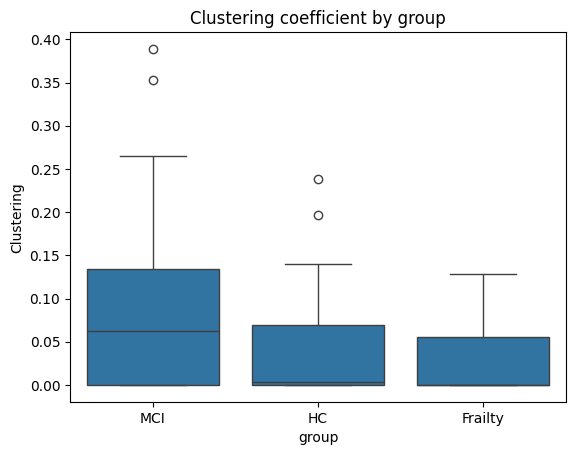

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="group", y="Clustering", data=df_resp)
plt.title("Clustering coefficient by group")
plt.show()


## Semantic clusters

In [44]:
features = ["Entropy", "Density", "Clustering", "NumNodes", "NumArches"]

from sklearn.preprocessing import StandardScaler

X = df_resp[features].dropna()
idx_valid = X.index  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 3

# K-means clustering
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

#Silhouette score
silhouette = silhouette_score(X_scaled, clusters)
print(f"Silhouette score (k={k}): {silhouette:.3f}")

df_resp.loc[idx_valid, "SemanticClustering"] = clusters

/root/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Silhouette score (k=3): 0.422


In [45]:
df_resp.groupby("SemanticClustering")[features].mean().round(2)

,Entropy,Density,Clustering,NumNodes,NumArches
SemanticClustering,,,,,
0.0,4.99,0.08,0.07,37.88,51.22
1.0,3.91,0.15,0.07,17.33,19.89
2.0,2.40,0.41,0.03,5.87,5.20


In [46]:
pd.crosstab(df_resp["group"], df_resp["SemanticClustering"])

SemanticClustering,0.0,1.0,2.0
group,,,
Frailty,5,12,3
HC,12,14,6
MCI,23,28,6


In [47]:
df_resp.groupby("SemanticClustering")[features].mean().round(2)


,Entropy,Density,Clustering,NumNodes,NumArches
SemanticClustering,,,,,
0.0,4.99,0.08,0.07,37.88,51.22
1.0,3.91,0.15,0.07,17.33,19.89
2.0,2.40,0.41,0.03,5.87,5.20


In [48]:
import scipy.stats as stats

ct = pd.crosstab(df_resp["group"], df_resp["SemanticClustering"])

chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-quadro = {chi2:.2f}, p = {p:.4f}")

Chi-quadro = 2.65, p = 0.6174


In [49]:
df_resp.to_csv("df_resp.csv", index=False)

# PIT & Verbal Fluency

In [50]:
df_merged = pd.read_csv("df_merged (SVF+NPS).csv")

df_merged["id"] = df_merged["id"].astype(str)      
df_resp["id"] = df_resp["id"].astype(str)

df_resp_renamed = df_resp.rename(
    columns={col: f"{col}_PIT" for col in df_resp.columns if col not in ["id", "group"]}
)

df = pd.merge(df_merged, df_resp_renamed, on=["id", "group"], how="inner")

print(f"Tot subjects: {len(df)}")
df.head()

Tot subjects: 109


,id,group,Gender,Age,Education level,MMSE,Corsi D.,Digit D.,Supraspan,TMT-A,...,correct answer_PIT,elements_PIT,n° elements_PIT,clean answers_PIT,NumNodes_PIT,NumArches_PIT,Clustering_PIT,Density_PIT,Entropy_PIT,SemanticClustering_PIT
0,1,MCI,F,77,13,27.3,6.24,5.27,25.63,13,...,0,"ragazzi, signore, schermo, fili",4.0,"[qualcosa, non, andare, tutto, essere, perples...",31,45,0.162617,0.096774,4.703546,0.0
1,2,MCI,M,78,13,27.3,3.24,7.27,26.88,36,...,0,"ragazzi, chiave, parete",2.0,"[ci, essere, tre, ragazzo, e, uno, ragazzo, ch...",21,26,0.057823,0.123810,4.178108,1.0
2,3,MCI,F,67,8,27.0,4.25,5.23,7.06,45,...,0,"ragazze, tv",2.0,"[due, ragazzo, che, guardare, il, televisione,...",29,39,0.076820,0.096059,4.656445,0.0
3,4,MCI,F,76,8,28.0,6.50,6.49,6.13,5,...,1,"ragazze, sedia",2.0,"[c, e, uno, ragazzare, che, e, su il, sediare,...",24,29,0.062500,0.105072,4.467823,1.0
4,5,MCI,M,81,8,26.7,4.66,6.65,10.66,35,...,1,"tv, occhiali",2.0,"[non, nulla, avere, rompere, il, macchina, e, ...",24,33,0.264899,0.119565,4.277984,1.0


In [53]:
def avg_across_categories(df, base_name, categories):
    return df[[f"{base_name}_{cat}" for cat in categories]].mean(axis=1)

categories = ["animals", "colors", "fruits"]

df["switch_rate_tot"] = avg_across_categories(df, "switch_rate", categories)
df["cluster_switches_tot"] = avg_across_categories(df, "cluster_switches", categories)
df["cluster_size_tot"] = avg_across_categories(df, "cluster_size", categories)
df["perseverations_tot"] = avg_across_categories(df, "perseverations", categories)
df["intrusions_tot"] = avg_across_categories(df, "intrusions", categories)
df["word_freq_tot"] = avg_across_categories(df, "word_freq", categories)
df["aoa_tot"] = avg_across_categories(df, "aoa", categories)

df.head()

,id,group,Gender,Age,Education level,MMSE,Corsi D.,Digit D.,Supraspan,TMT-A,...,Density_PIT,Entropy_PIT,SemanticClustering_PIT,switch_rate_tot,cluster_switches_tot,cluster_size_tot,perseverations_tot,intrusions_tot,word_freq_tot,aoa_tot
0,1,MCI,F,77,13,27.3,6.24,5.27,25.63,13,...,0.096774,4.703546,0.0,0.490000,5.666667,1.626667,0.000000,1.666667,1757.083333,4.593333
1,2,MCI,M,78,13,27.3,3.24,7.27,26.88,36,...,0.123810,4.178108,1.0,0.433333,7.000000,2.040000,0.000000,1.000000,1305.866667,4.570000
2,3,MCI,F,67,8,27.0,4.25,5.23,7.06,45,...,0.096059,4.656445,0.0,0.426667,4.833333,1.553333,0.666667,0.333333,2223.640000,3.926667
3,4,MCI,F,76,8,28.0,6.50,6.49,6.13,5,...,0.105072,4.467823,1.0,0.453333,7.000000,1.726667,0.000000,1.666667,1681.440000,4.233333
4,5,MCI,M,81,8,26.7,4.66,6.65,10.66,35,...,0.119565,4.277984,1.0,0.436667,4.000000,2.223333,0.000000,0.000000,2455.073333,4.203333


In [56]:
df.to_csv("df_merged (semantic+nps).csv", index=False)

In [59]:
from scipy.stats import kruskal
import scikit_posthocs as sp
import itertools


metrics_to_test = [
        "switch_rate_tot", "cluster_switches_tot", "cluster_size_tot", "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot", 
        "NumNodes_PIT","NumArches_PIT","Clustering_PIT","Density_PIT","Entropy_PIT"
]

num_comparisons = 3
bonferroni_thresholds = {
    0.05: 0.05 / num_comparisons,
    0.01: 0.01 / num_comparisons,
    0.001: 0.001 / num_comparisons
}

for metric in metrics_to_test:
    print(f"Metric: {metric}")

    groups = [g[metric].dropna() for _, g in df.groupby("SemanticClustering_PIT")]

    # Kruskal-Wallis's test
    H, p_kw = kruskal(*groups)
    print(f"Kruskal-Wallis: H = {H:.2f}, p = {p_kw:.4f}")

    if p_kw < 0.05:
        print("→ Significative: post-hoc test (with Bonferroni)")
        
        #  post-hoc Dunn's test + Bonferroni
        data = df[[metric, "SemanticClustering_PIT"]].dropna()
        posthoc = sp.posthoc_dunn(data, val_col=metric, group_col="SemanticClustering_PIT", p_adjust="bonferroni")
        
   
        for i, j in itertools.combinations(posthoc.columns, 2):
            p_val = posthoc.loc[i, j]
            significance = ""
            if p_val < bonferroni_thresholds[0.001]:
                significance = "***"
            elif p_val < bonferroni_thresholds[0.01]:
                significance = "**"
            elif p_val < bonferroni_thresholds[0.05]:
                significance = "*"
            print(f"  Cluster {i} vs Cluster {j}: p = {p_val:.4f} {significance}")
    else:
        print("→ Not significative (p ≥ 0.05)")

Metric: switch_rate_tot
Kruskal-Wallis: H = 2.86, p = 0.2399
→ Not significative (p ≥ 0.05)
Metric: cluster_switches_tot
Kruskal-Wallis: H = 4.16, p = 0.1248
→ Not significative (p ≥ 0.05)
Metric: cluster_size_tot
Kruskal-Wallis: H = 0.99, p = 0.6086
→ Not significative (p ≥ 0.05)
Metric: perseverations_tot
Kruskal-Wallis: H = 0.67, p = 0.7165
→ Not significative (p ≥ 0.05)
Metric: intrusions_tot
Kruskal-Wallis: H = 3.97, p = 0.1372
→ Not significative (p ≥ 0.05)
Metric: word_freq_tot
Kruskal-Wallis: H = 1.34, p = 0.5108
→ Not significative (p ≥ 0.05)
Metric: aoa_tot
Kruskal-Wallis: H = 0.81, p = 0.6686
→ Not significative (p ≥ 0.05)
Metric: NumNodes_PIT
Kruskal-Wallis: H = 89.30, p = 0.0000
→ Significative: post-hoc test (with Bonferroni)
  Cluster 0.0 vs Cluster 1.0: p = 0.0000 ***
  Cluster 0.0 vs Cluster 2.0: p = 0.0000 ***
  Cluster 1.0 vs Cluster 2.0: p = 0.0005 **
Metric: NumArches_PIT
Kruskal-Wallis: H = 89.21, p = 0.0000
→ Significative: post-hoc test (with Bonferroni)
  Clust

In [62]:
fluency_metrics = ["switch_rate_tot", "cluster_switches_tot", "cluster_size_tot",
                   "perseverations_tot", "intrusions_tot", "word_freq_tot", "aoa_tot"]

pit_metrics = ["NumNodes_PIT", "NumArches_PIT", "Clustering_PIT", "Density_PIT",
               "Entropy_PIT", "Clustering_PIT","SemanticClustering_PIT"]

df_fluency_long = df.melt(id_vars=["id", "group"], value_vars=fluency_metrics,
                          var_name="Measure", value_name="Value")
df_fluency_long["Task"] = "fluency"

df_pit_long = df.melt(id_vars=["id", "group"], value_vars=pit_metrics,
                      var_name="Measure", value_name="Value")
df_pit_long["Task"] = "PIT360"

df_long = pd.concat([df_fluency_long, df_pit_long], ignore_index=True)
df_long = df_long[["id", "group", "Task", "Measure", "Value"]]  

df_long.head()

,id,group,Task,Measure,Value
0,1,MCI,fluency,switch_rate_tot,0.490000
1,2,MCI,fluency,switch_rate_tot,0.433333
2,3,MCI,fluency,switch_rate_tot,0.426667
3,4,MCI,fluency,switch_rate_tot,0.453333
4,5,MCI,fluency,switch_rate_tot,0.436667


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=970a50dd-d838-4190-8c0b-17ac60744345' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>